/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

===== 5 Fold Cross Validation Results =====

EWM RMSE : 25.0598
RF RMSE : 3.9744
XGB RMSE : 3.6983
DL RMSE : 5.1996

Best weighting model: XGB


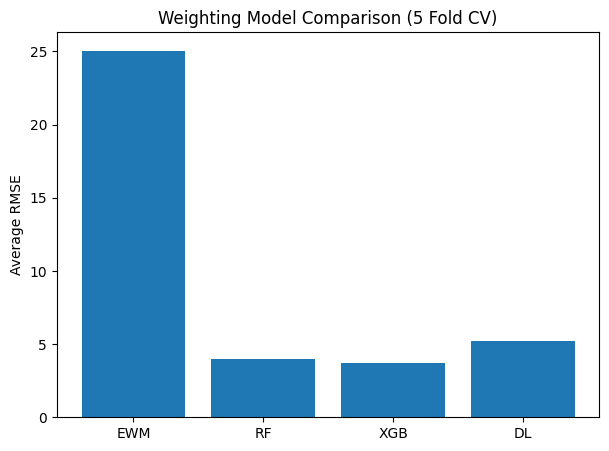

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# =========================
# Load Data
# =========================

def load_data(file_path):

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip().str.replace('\ufeff','')

    df['name'] = df['name'].astype(str).str.strip()
    df['team_name'] = df['team_name'].astype(str).str.strip()
    df['position_short'] = df['position_short'].astype(str).str.upper().str.strip()

    df['position_short'] = df['position_short'].replace({
        'F':'FW','FWD':'FW','ST':'FW',
        'M':'MF','MID':'MF',
        'D':'DF','DEF':'DF',
        'GK':'GK','G':'GK'
    })

    df.fillna(0,inplace=True)

    return df


# =========================
# EWM
# =========================

def compute_ewm_weights(X):

    data = X.astype(float).values

    col_sums = np.maximum(data.sum(axis=0),1e-12)

    P = data / col_sums

    n = P.shape[0]

    k = 1 / np.log(n)

    entropy = -k*np.nansum(P*np.log(P+1e-12),axis=0)

    divergence = 1-entropy

    weights = divergence/divergence.sum()

    return weights


# =========================
# K-Fold Evaluation
# =========================

def evaluate_models_kfold(X):

    y = X.sum(axis=1)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    rmse_rf=[]
    rmse_xgb=[]
    rmse_dl=[]
    rmse_ewm=[]

    for train_index, test_index in kf.split(X):

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # =================
        # Random Forest
        # =================

        rf = RandomForestRegressor(n_estimators=300, random_state=42)

        rf.fit(X_train,y_train)

        pred_rf = rf.predict(X_test)

        rmse_rf.append(np.sqrt(mean_squared_error(y_test,pred_rf)))

        # =================
        # XGBoost
        # =================

        xgb = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            objective='reg:squarederror'
        )

        xgb.fit(X_train,y_train)

        pred_xgb = xgb.predict(X_test)

        rmse_xgb.append(np.sqrt(mean_squared_error(y_test,pred_xgb)))

        # =================
        # Deep Learning
        # =================

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = Sequential([
            Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
            Dense(16, activation='relu'),
            Dense(1)
        ])

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse'
        )

        model.fit(
            X_train_scaled,
            y_train,
            epochs=50,
            batch_size=16,
            verbose=0
        )

        pred_dl = model.predict(X_test_scaled).flatten()

        rmse_dl.append(np.sqrt(mean_squared_error(y_test,pred_dl)))

        # =================
        # EWM
        # =================

        weights = compute_ewm_weights(X_train)

        pred_ewm = X_test.dot(weights)

        rmse_ewm.append(np.sqrt(mean_squared_error(y_test,pred_ewm)))

    results = {
        "EWM": np.mean(rmse_ewm),
        "RF": np.mean(rmse_rf),
        "XGB": np.mean(rmse_xgb),
        "DL": np.mean(rmse_dl)
    }

    print("\n===== 5 Fold Cross Validation Results =====\n")

    for model,score in results.items():

        print(f"{model} RMSE : {score:.4f}")

    best_model = min(results,key=results.get)

    print("\nBest weighting model:",best_model)

    return results


# =========================
# Main
# =========================

def main():

    file_path = "/Users/aranyabasu/Desktop/dataanalysislearning/project_final/source_code/final_year_project_dataset.csv"

    df = load_data(file_path)

    position = input("Enter position (FW, MF, DF, GK): ").upper()

    if position == "FW":

        stats=[
            'events.goals',
            'events.assists',
            'events.shots_on_target',
            'events.key_passes',
            'touches.successful_passes'
        ]

    elif position == "MF":

        stats=[
            'events.assists',
            'events.key_passes',
            'events.chances_created',
            'touches.successful_passes',
            'touches.interceptions'
        ]

    elif position == "DF":

        stats=[
            'touches.tackles',
            'touches.blocks',
            'touches.interceptions',
            'touches.clearance'
        ]

    else:

        stats=[
            'goaltenders.saves',
            'goaltenders.shots_faced',
            'events.cleansheet'
        ]


    position_df = df[df['position_short']==position].copy()

    X = position_df[stats].astype(float)

    results = evaluate_models_kfold(X)

    # ======================
    # Plot Comparison
    # ======================

    plt.figure(figsize=(7,5))

    models=list(results.keys())
    scores=list(results.values())

    plt.bar(models,scores)

    plt.ylabel("Average RMSE")
    plt.title("Weighting Model Comparison (5 Fold CV)")

    plt.show()


if __name__=="__main__":

    main()

1. Objective of the Project

The goal of this program is to analyze football player performance and determine the best weighting method for evaluating players.

Different machine learning models are tested to see which method predicts player performance most accurately.

The models compared are:

1.Entropy Weight Method (EWM)
2.Random Forest
3.XGBoost
4.Deep Learning Neural Network

The comparison is done using 5-Fold Cross Validation with RMSE evaluation.

2. Libraries Used

Your code imports several Python libraries.

1.Data Processing

pandas → used for reading and manipulating datasets
numpy → used for numerical computations

2.Visualization

matplotlib → used to create comparison graphs

3.Machine Learning

scikit-learn
KFold → cross validation
StandardScaler → feature normalization
RandomForestRegressor → ML model
mean_squared_error → evaluation metric

4.Gradient Boosting

XGBoost → powerful boosting algorithm for regression

5.Deep Learning

TensorFlow / Keras
      Sequential → neural network model
      Dense → fully connected layers
      Adam → optimizer


3. Data Loading and Cleaning

Function used:

load_data(file_path)
What this function does

1️⃣ Loads the dataset

df = pd.read_csv(file_path)

This reads the CSV dataset containing football player statistics.

2️⃣ Cleans column names

df.columns = df.columns.str.strip().str.replace('\ufeff','')

Removes:

extra spaces
invisible characters from CSV files

3️⃣ Cleans player information

df['name'] = df['name'].astype(str).str.strip()
df['team_name'] = df['team_name'].astype(str).str.strip()

Ensures:

values are strings
removes extra spaces

4️⃣ Standardizes player positions

Football positions often appear in different formats.

Example:

Raw	Converted
ST	FW
FWD	FW
MID	MF
DEF	DF

Code used:

df['position_short'] = df['position_short'].replace({...})

This ensures all players have consistent position labels.

5️⃣ Handles missing values

df.fillna(0,inplace=True)

Missing statistics are replaced with 0 so that models do not crash.

4. Entropy Weight Method (EWM)

Function:

compute_ewm_weights(X)

EWM is a statistical weighting method used in multi-criteria decision analysis.

Idea:Features that have more variation across players carry more information, so they receive higher weight.

Step 1 — Convert to numeric matrix
data = X.astype(float).values

Step 2 — Normalize the data
P = data / col_sums

This converts statistics into probabilities.

Step 3 — Calculate entropy

Entropy measures disorder or uncertainty.
High entropy → feature has less importance
Low entropy → feature has more importance

Step 4 — Calculate divergence
divergence = 1 - entropy

This measures useful information contained in each feature.

Step 5 — Compute weights
weights = divergence / divergence.sum()

This produces feature importance weights.

Example:

Feature	     Weight
Goals	      0.35
Assists	      0.25
Shots	      0.20
Passes	      0.20

5. Model Evaluation Using K-Fold Cross Validation

Function: evaluate_models_kfold(X)

Target Variable:y = X.sum(axis=1)

The performance score is calculated as the sum of all selected statistics.

Why Cross Validation?
=>Instead of splitting data once, K-Fold splits the dataset multiple times.

In this code: 5 folds

Process:

Split dataset into 5 parts
Train on 4 parts
Test on remaining part
Repeat 5 times

This gives more reliable performance evaluation.

6. Machine Learning Models Used

1️⃣ Random Forest

RandomForestRegressor(n_estimators=300)

Random Forest is an ensemble model that combines many decision trees.

Advantages:

Handles nonlinear relationships
Resistant to overfitting
Works well with tabular data

Prediction example: pred_rf = rf.predict(X_test)

2️⃣ XGBoost

XGBRegressor(
n_estimators=400,
learning_rate=0.05,
max_depth=4
)

XGBoost is a boosting algorithm.It improves performance by sequentially correcting previous errors.

Advantages:

Very high predictive power
Often wins machine learning competitions

3️⃣ Deep Learning Model

A Neural Network is created using TensorFlow.

Architecture:

Input Layer
   ↓
Dense Layer (32 neurons, ReLU)
   ↓
Dense Layer (16 neurons, ReLU)
   ↓
Output Layer (1 neuron)

Code:

model = Sequential([
Dense(32, activation='relu'),
Dense(16, activation='relu'),
Dense(1)
])

Training:

epochs = 50
batch_size = 16

Data Scaling: Neural networks require normalized input.
              StandardScaler()

Transforms features to:

mean = 0
standard deviation = 1


7. Model Evaluation Metric

All models are evaluated using RMSE.

Root Mean Squared Error:

RMSE=sqrt(1/n∑(Ytrue-Ypred)^2)	​

Meaning: 
    Measures prediction error
    Lower RMSE = better model

8. EWM Prediction

Instead of training a model, EWM directly calculates weighted score.

pred_ewm = X_test.dot(weights)

This multiplies player statistics with entropy weights.

Example:

Score = (Goals × weight1)
      + (Assists × weight2)
      + (Shots × weight3)

9. Model Comparison

After cross validation, the average RMSE is calculated.

Example output:

===== 5 Fold Cross Validation Results =====

EWM RMSE : 1.23
RF RMSE : 0.98
XGB RMSE : 0.92
DL RMSE : 1.05

Best weighting model: XGB

The lowest RMSE indicates the best model.

10. Position-Based Analysis

The model analyzes players based on position.

User input:

Enter position (FW, MF, DF, GK)

Each position uses different statistics.

Example:

Forward (FW)

Goals
Assists
Shots on target
Key passes

Midfielder (MF)

Assists
Key passes
Chances created
Passes

Defender (DF)

Tackles
Blocks
Interceptions
Clearances

Goalkeeper (GK)

Saves
Shots faced
Clean sheets

This makes evaluation position-specific and realistic.


11. Overall Workflow

The full pipeline works like this:

Load Dataset
      ↓
Clean Data
      ↓
Select Position
      ↓
Extract Relevant Stats
      ↓
Apply 5-Fold Cross Validation
      ↓
Train Models
   • Random Forest
   • XGBoost
   • Deep Learning
   • Entropy Weight Method
      ↓
Calculate RMSE
      ↓
Compare Models
      ↓
Visualize Results


12. Key Contribution of the Project

This project demonstrates how machine learning can evaluate football player performance more objectively.

Benefits:

Removes human bias
Uses statistical data
Compares multiple AI models
Identifies the most accurate evaluation method
